In [1]:
import sys
from pathlib import Path

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# --- standard library -----------------------------------------------------
import json
import logging
from collections import Counter

# --- third party ----------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- project --------------------------------------------------------------
import config
from src.data import fetch_poems, generate, splits
from src.data import filter as data_filter  # `filter` alone shadows the builtin
from src.plots import figures
from src.eval import format_check, grounding

%load_ext autoreload
%autoreload 2

# One logging setup for every notebook. Also quietens the HTTP and hub loggers
# that would otherwise bury this project's own output — see config for why each
# suppression is safe.
config.configure_logging()

# 2 — Exploratory data analysis

`01_data.ipynb` built the corpus and measured the **teacher**. This notebook
asks what the corpus *is*, and it is deliberately a separate notebook: the two
answer different questions, and mixing them meant reporting the same counts
twice from two code paths that could disagree.

Everything here reads the cached artifacts. Nothing calls an API, nothing is
regenerated, and re-running is free.

**There is no feature engineering.** This is causal language modelling over raw
text — no tabular features, no encoding, no scaling, nothing fitted on the data
that could leak across a split. The absence is a property of the task, not an
omission, and it is why the partition can be computed at the end of this
notebook rather than before it.

Three questions, in order:

1. **What is in the corpus** — length, author skew, and the sampling biases
   every later result is conditional on.
2. **What the training targets look like** — length, quoting behaviour, and
   whether the tone slot carries information or is filled from habit.
3. **How it partitions** — 5-fold grouped cross-validation, and whether the
   folds come out balanced enough to use.

In [2]:
# Everything is cached: the fetch is on disk, the interpretations are on disk,
# and the funnel is deterministic. This rebuilds the same corpus 01 produced.
raw_poems = fetch_poems.load_cached()
interpretations = generate.load_cached()
corpus, funnel = data_filter.build_corpus(raw_poems, interpretations)

print(f"{len(corpus)} poems in the corpus, "
      f"from {len({p['author'] for p in corpus})} authors")

INFO dropped 75 duplicate records
INFO corpus: 2536 poems from 3081 raw


2536 poems in the corpus, from 127 authors


## What is in the corpus

Every result in this project is conditional on this particular collection, so
the shape of it is a finding rather than a preamble.

**Author distribution is not decorative.** It feeds the central measurement
twice. Folds are grouped by author, so the largest collections determine how
balanced the partition can be — one very prolific poet can skew a fold badly.
And the strict swap condition scores an interpretation against *a different
poem by the same author*, which only exists for authors holding more than one
poem in the corpus.

**The named biases.** The corpus is bounded below at 8 lines and above by a
token budget, so it is biased toward shorter work and says nothing about
epigrams or couplets. Evaluation poems are drawn only from authors with a
sibling, which biases the evaluation set toward prolific, heavily-anthologised
poets — which is also where author-prior leakage is strongest, so that bias
runs *against* this project's own conclusions rather than in their favour.

INFO wrote /Users/adelinchaushev/Desktop/PoetryIntepretations./results/figures/02_corpus_statistics.png


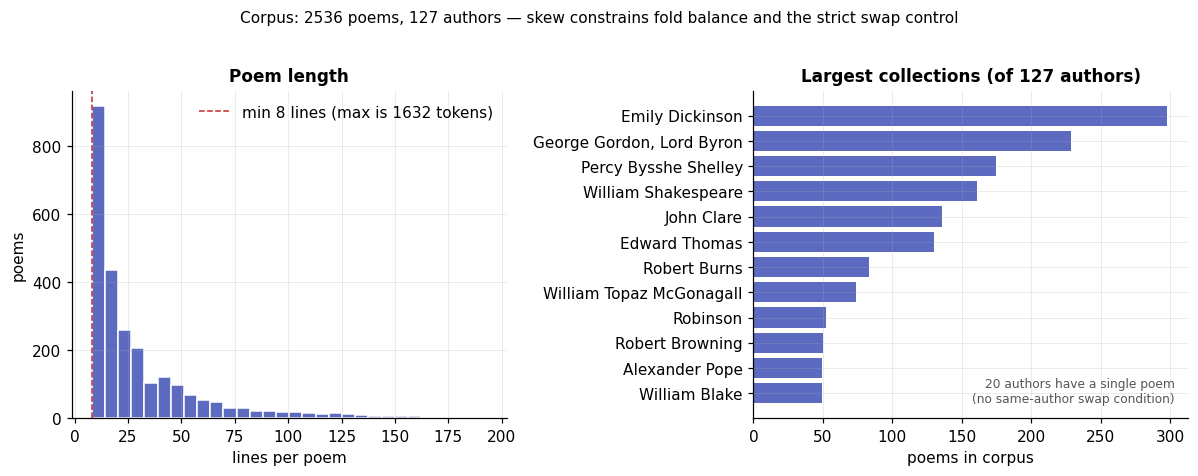

In [3]:
# Figure 2 — the trailing `;` suppresses the returned path; the figure itself
# is drawn once, by the inline backend.
figures.corpus_statistics(corpus);

**Figure 2 — Corpus composition.** *Left:* poems per line count, with the
8-line floor marked. The upper bound is a token budget, so it corresponds to no
single vertical line here — line length varies enough that a longer poem can fit
where a shorter one does not. *Right:* the largest author collections, annotated
with how many authors hold only one poem. Those authors can never supply the
same-author swap condition, which is why the evaluation set is drawn only from
authors with a sibling.

## What the training targets look like

The funnel records only what was *rejected*. These are properties of what
survived, and they are properties of the **teacher** — the student's ceiling.

**Length**, because arms are later compared on judge scores and a longer answer
can score better for reasons unrelated to grounding. Fixing the teacher's
distribution here means verbosity is a measured variable later rather than an
uncontrolled one.

**Quote count**, because the grounding check is only as discriminating as the
number of quotes it has to check.

**Share of the poem inside quotes**, which is the measurement the 8-line floor
was derived from: as poems shorten, three quoted spans approach the whole text,
and at that point reproducing the poem scores as perfectly grounded while
saying nothing.

INFO wrote /Users/adelinchaushev/Desktop/PoetryIntepretations./results/figures/02b_interpretation_statistics.png


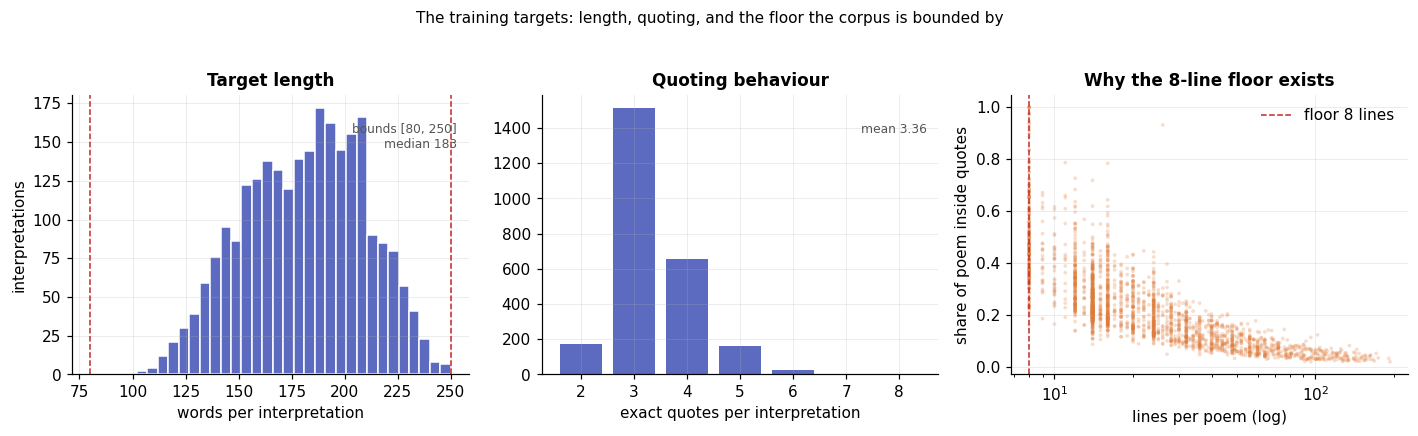

In [4]:
figures.interpretation_statistics(corpus);

**Figure 2b — The training targets.** *Left:* interpretation length in
words, with the filter bounds marked; the funnel rejects outside them, so the
visible spread is what survived. *Centre:* how many exact quotes each
interpretation contains — the grounding check is only as discriminating as the
number of quotes it has to verify. *Right:* the share of each poem sitting
inside quotes, against poem length on a log axis. This is the panel the 8-line
floor was derived from: the share rises sharply as poems shorten, and below the
floor three quoted spans approach the whole text, at which point reproducing the
poem would score as perfectly grounded while saying nothing.

### Is the tone slot filled from habit?

This is the failure no other check would catch. An interpretation can follow
the four-part schema, quote the poem accurately, clear every funnel stage, and
still say *"reflective and somewhat melancholy"* about every poem in the
corpus — carrying no information about the poem in front of it.

It matters because these are the training targets. A word appearing in most
outputs is one the student would learn to emit unconditionally, and it would
read as well-formed output while being exactly the interpretation-shaped text
this project exists to detect.

The line marks `config.TONE_DOMINANCE_WARN`. Nothing is dropped for crossing
it — it is a threshold for reading the chart, not a filter.

INFO wrote /Users/adelinchaushev/Desktop/PoetryIntepretations./results/figures/02c_tone_vocabulary.png


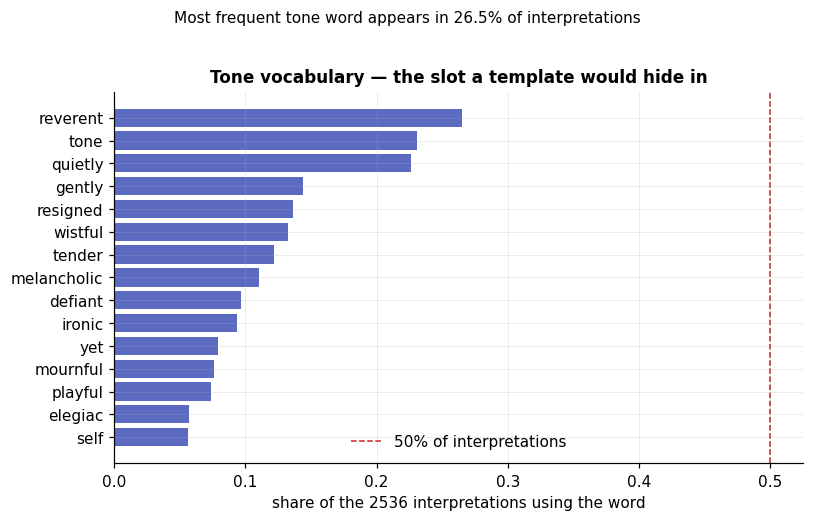

In [5]:
figures.tone_vocabulary(corpus);

**Figure 2c — Tone vocabulary.** Share of interpretations using each of the
most frequent words in the tone slot, with `TONE_DOMINANCE_WARN` marked. Bars
crossing that line are drawn in the warning colour. A word appearing in most
outputs would mean the teacher is filling the slot from habit rather than from
reading, and since these are the training targets, the student would learn the
word instead of the judgement. Nothing is dropped for crossing the line — it is
a threshold for reading the chart, not a filter.

### Where in the poem does the teacher quote from?

A teacher that read only the opening would still pass every grounding check —
a quote from line 2 is exactly as verbatim as a quote from line 40. **Position
is what separates reading a poem from skimming it, and no grounding rate would
ever notice the difference.**

It also bears on the length bias. If quotes clustered near the start, the tail
of a long poem would never be examined, and the corpus's bias toward shorter
work would matter less than the drop counts suggest — the teacher would have
been treating long poems as short ones anyway.

INFO wrote /Users/adelinchaushev/Desktop/PoetryIntepretations./results/figures/02d_quote_positions.png


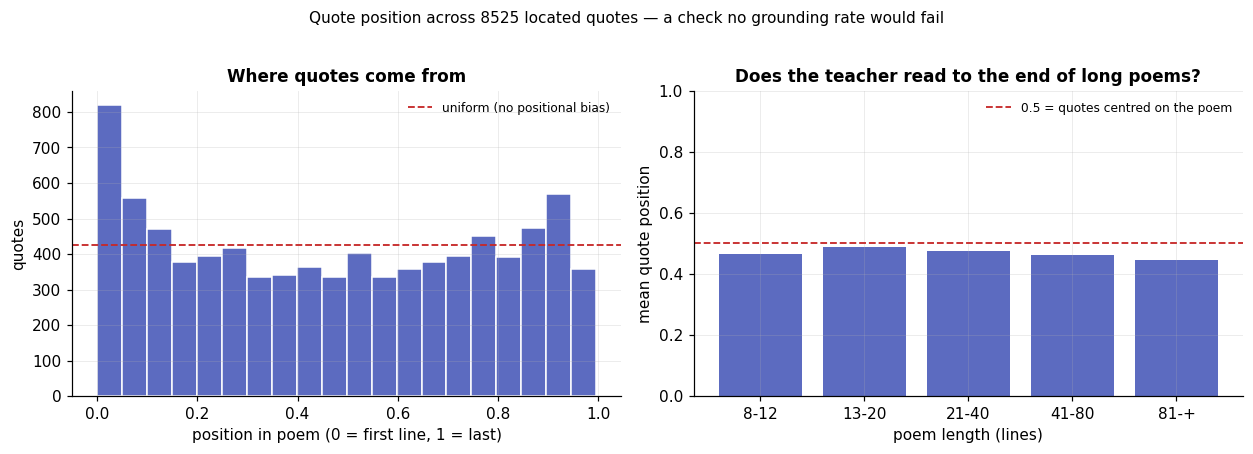

In [6]:
figures.quote_positions(corpus);

**Figure 2d — Quote position.** *Left:* where each located quote falls in
its poem, 0 being the first line and 1 the last, against a uniform reference
line. Mass piled near 0 would mean the teacher reads only the opening. *Right:*
mean position within poem-length bands, against 0.5 for quotes centred on the
poem. A downward trend across the bands would mean attention shortens as poems
lengthen — the tail of a long poem going unread. Neither pattern is visible in
any grounding rate, since a quote from line 2 is exactly as verbatim as one from
line 40.

### Does author identity alone predict anything?

This tests the assumption the **strict swap condition rests on**, and it can be
settled before a model is trained. The swap test scores an interpretation
against a different poem *by the same author* because an author's manner
recurs: a model that learned "Dickinson writes about death and immortality"
could emit a plausible interpretation for an unseen Dickinson poem without
reading it. The same-author condition closes that route — **but only if author
identity is actually recoverable from the text.**

#### Left panel: lexical similarity, and why it settles nothing

Poems become TF-IDF vectors — each word weighted by how often it occurs in the
poem times $\ln\frac{1+n}{1+\text{df}(t)}+1$, so rare words count for more —
then scaled to unit length, which makes cosine similarity a plain dot product
over shared words.

Two statistics are reported on the panel, and they disagree in an instructive
way. The **ratio of means** looks large; the **AUC** does not. AUC is
$P(\text{a random same-author pair scores higher than a random cross-author
pair})$, where 0.5 means no signal at all. It is the trustworthy one here,
because both means sit near zero on a heavily right-skewed distribution, where
a ratio exaggerates separation and a handful of high-overlap pairs can carry it.

Worse, cosine over words cannot separate what a poem is *about* from who wrote
it. Two poets writing about death score alike for the wrong reason.

#### Right panel: authorship attribution, which does settle it

Multinomial logistic regression over the authors holding at least
`MIN_POEMS_FOR_ATTRIBUTION` poems, scored by stratified 4-fold
cross-validation. **The vectoriser is fitted inside each fold**, not once over
the whole corpus — fitting it first would compute idf weights, and for two of
the three feature sets the vocabulary itself, from the held-out poems.

Three feature sets, because *which* one carries the signal changes what it means:

| Features | What accuracy there would mean |
|---|---|
| content words | topic — poets may simply write about different subjects |
| **function words** | *the, of, and, but*: **no subject matter at all**. Classical stylometry, so accuracy here is style, independent of topic |
| character 3–5 grams | morphology and diction together; least interpretable |

Two reference lines. The **majority class** is what a constant predictor
scores. The **shuffled-label null** is the same pipeline with author labels
permuted — that is the line that rules out leakage, rather than merely stating
class balance, and it is the one to read the bars against.

Content-word accuracy could be explained away as topic. Function-word accuracy
could not, and that is the leak the same-author condition exists to close.

#### What this does not show

The classifier is trained on this corpus, so it is an **upper bound** on how
legible authorship is to a model that has seen these poets. Qwen's exposure
came through pretraining, a different route, so the claim is "author identity
is recoverable from poem text" — not a figure for what Qwen recovers.
Restricting to the most prolific authors also inflates accuracy relative to the
full 127-way problem, and the permutation p-value floors at
$1/(N_\text{perm}+1)$, so the null's *mean accuracy* is the informative output
rather than the p-value.

**This measures signal in the poems, not whether the judge is moved by it.**
That is a different question, and only the judge can answer it — the swap test
run on teacher outputs, in `04_evaluation.ipynb`, is the measurement this
figure is a cheap prior for.

INFO wrote /Users/adelinchaushev/Desktop/PoetryIntepretations./results/figures/02e_author_signal.png


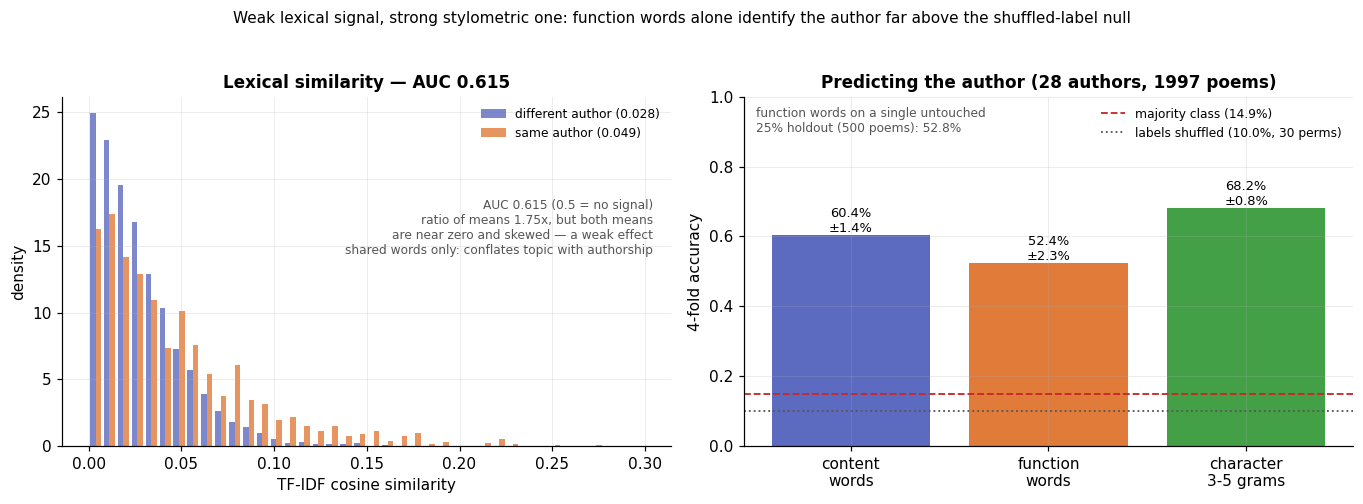

In [7]:
# Near-duplicates are excluded inside the figure: PoetryDB publishes some poems
# under several titles, and a "same author" pair that is the same text twice
# would inflate the very number this figure exists to establish.
figures.author_signal(corpus);

**Figure 2e — Author signal.** *Left:* TF-IDF cosine similarity for
same-author against different-author poem pairs, with AUC — the probability a
random same-author pair outscores a random cross-author pair, where 0.5 is no
signal. Read the AUC, not the ratio of means: both means sit near zero on a
skewed distribution where a ratio exaggerates separation. *Right:* accuracy of a
linear model predicting the author from held-out poems, over three feature sets,
with per-fold spread in each label. Two reference lines: the majority class is
what a constant predictor scores; the shuffled-label null is the same pipeline
with labels permuted, and that is the line the bars should be read against. The
function-word bar is the load-bearing one — those features carry no subject
matter, so accuracy there is style rather than topic.

### What the sequence budget has to hold

The measurement that defends `MAX_SEQ_LEN`. Attention on P100/T4 is quadratic
in sequence length, so the cap is a memory decision — and it is only defensible
against the distribution it has to cover.

Two things to read off it:

**The cap does not bind.** It sits far above p99, which is the same fact the
funnel states when its `fits context` stage drops zero poems. Nothing is
truncated, and nothing needs to be — a pair that does not fit is dropped
instead, because truncating would let the grounding checker match a quote
against text the model never saw.

**The median sits far below the cap**, which is what makes dynamic padding
worth the trouble rather than an optimisation. Padding every batch to
`MAX_SEQ_LEN` would spend most of the compute on padding tokens.

INFO wrote /Users/adelinchaushev/Desktop/PoetryIntepretations./results/figures/02f_training_pair_tokens.png


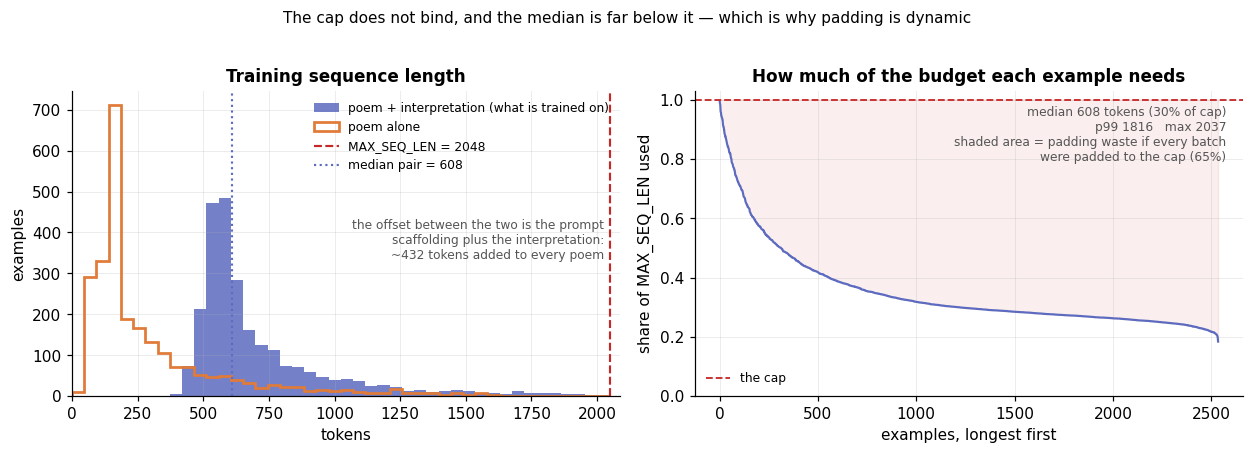

In [8]:
figures.training_pair_tokens(corpus);

**Figure 2f — The sequence budget.** *Left:* token counts for the poem
alone (outline) and for the full training pair (filled), with `MAX_SEQ_LEN` and
the median marked. The offset between the two distributions is the prompt
scaffolding plus the interpretation — a near-constant cost added to every poem.
*Right:* the same pairs sorted longest first, as a share of the cap. The shaded
region above the curve is what a fixed-cap batch would spend on padding tokens;
its size is the argument for dynamic padding. That the curve meets the cap only
at its extreme left is the same fact the funnel reports when its `fits context`
stage drops nothing.

## How it partitions

**5-fold grouped cross-validation, grouped by author.** Poems by one author are
not independent samples — themes, diction and preoccupations recur — so
training on one Dickinson poem carries information about every other Dickinson
poem. A poem-level split would put correlated items on both sides of the
partition: the same violation as letting one patient's scans straddle train and
test.

The partition is computed **once, here, with a fixed seed**, and shipped to
Kaggle as data. Recomputing it there would break the held-out guarantee
silently — nothing would raise, and every grounding number would quietly
improve.

Exemplars are reserved first, and their **authors** are excluded from the folds
entirely: a few-shot example by Dickinson sitting in every prompt while
Dickinson also occupies an evaluation fold would leak her themes through the
prompt rather than through the weights — the same failure by a different route.

The assertions below are the ones that fail silently into a plausible-looking
result if omitted.

In [9]:
# Exemplars first, so they — and their authors — can be kept out of every fold.
exemplars = splits.reserve_exemplars(corpus, n=config.N_FEWSHOT, seed=config.SEED)

# GroupKFold: deterministic, no shuffling, largest groups placed first. The
# determinism is what lets this be computed here and shipped to Kaggle as data.
folds = splits.make_folds(corpus, config.N_FOLDS,
                          group_key=config.FOLD_GROUP_KEY,
                          seed=config.SEED, exclude=exemplars)

# 30 per fold rather than the full ~500 held out: this keeps the judge budget
# fixed regardless of corpus size, while guaranteeing every evaluated poem was
# held out by the model that generated for it.
eval_set = splits.sample_eval_poems(folds, config.EVAL_PER_FOLD, config.SEED)

print(splits.summary(folds, eval_set))

INFO excluding 3 group(s) reserved as exemplars: Anne Bronte, Robert Louis Stevenson, Sir Thomas Wyatt
INFO 5 folds, sizes [497, 497, 496, 496, 496] (from 124 authors)


5-fold grouped partition (2482 poems)
  fold 0:    497 poems    24 authors  train on  1985  eval  30
  fold 1:    497 poems    25 authors  train on  1985  eval  30
  fold 2:    496 poems    25 authors  train on  1986  eval  30
  fold 3:    496 poems    25 authors  train on  1986  eval  30
  fold 4:    496 poems    25 authors  train on  1986  eval  30


In [10]:
# Fold balance, checked while the corpus could still be rebalanced. Grouping by
# author means folds cannot be exactly equal — a single prolific poet can skew
# one badly, and that is far cheaper to find now than to diagnose as a strange
# result on day 7.
sizes = folds.sizes()
imbalance = (max(sizes) - min(sizes)) / (sum(sizes) / len(sizes))
print(f"fold sizes  {sizes}")
print(f"imbalance   {imbalance:.4f}   tolerance {config.MAX_FOLD_SIZE_IMBALANCE}\n")

# Each of these fails silently into a plausible-looking result if omitted.
checks = [
    ("every poem in exactly one fold",
     lambda: splits.assert_partition_complete(folds, corpus, exemplars)),
    ("no author spans two folds",
     lambda: splits.assert_no_author_across_folds(folds)),
    ("no eval poem in its own fold's training set",
     lambda: splits.assert_no_leakage(folds, eval_set)),
    ("exemplars disjoint from every eval set",
     lambda: splits.assert_exemplars_disjoint(eval_set, exemplars)),
    ("every eval poem has a same-author sibling",
     lambda: splits.assert_same_author_sibling_exists(eval_set, corpus)),
    ("fold imbalance within tolerance",
     lambda: splits.assert_balanced(folds, config.MAX_FOLD_SIZE_IMBALANCE)),
]
for name, check in checks:
    try:
        check()
        print(f"  PASS  {name}")
    except AssertionError as error:
        print(f"  FAIL  {name}: {error}")

fold sizes  [497, 497, 496, 496, 496]
imbalance   0.0020   tolerance 0.25

  PASS  every poem in exactly one fold
  PASS  no author spans two folds
  PASS  no eval poem in its own fold's training set
  PASS  exemplars disjoint from every eval set
  PASS  every eval poem has a same-author sibling
  PASS  fold imbalance within tolerance


### Do the folds come out balanced?

The partition is grouped by author, so fold sizes are determined by which
author-blocks land where. Dickinson and Byron alone account for a large share of
the corpus, and a fold that swallowed both would train on noticeably less data
than its siblings while being evaluated identically.

INFO wrote /Users/adelinchaushev/Desktop/PoetryIntepretations./results/figures/02g_fold_sizes.png


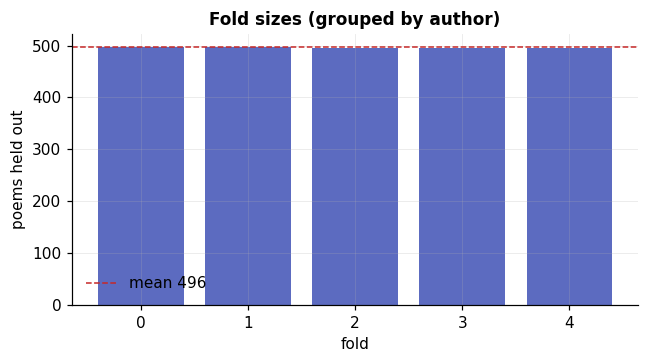

In [11]:
figures.fold_sizes(folds);

**Figure 2g — Fold sizes.** Poems held out by
each of the five folds. Grouping by author means the folds cannot come out
exactly equal — poems arrive in author-sized blocks, and one very prolific poet
can skew a fold badly. `GroupKFold` places the largest groups first into
whichever fold currently holds fewest, which is what keeps the imbalance small;
the printed figure above is checked against `MAX_FOLD_SIZE_IMBALANCE`.

This is checked here, at corpus-freezing time, precisely because it is cheap to
fix now and expensive to diagnose on day 7 as a strange per-fold result.

In [12]:
# Both artifacts, one call. The assignment names poem ids; the pairs file says
# which poems those are — shipping one without the other leaves Kaggle
# rebuilding the corpus from raw inputs, which agrees with the assignment right
# up until a filter threshold changes and then disagrees silently.
splits.save(folds, eval_set, exemplars, pairs=corpus)

for path in (config.FOLD_ASSIGNMENT_PATH, config.TRAINING_PAIRS_PATH):
    print(f"  {path.stat().st_size / 1024:>8.1f} KB  {path.name}")

INFO fold assignment written to /Users/adelinchaushev/Desktop/PoetryIntepretations./data/folds.json (2482 poems, 150 eval, 3 exemplars)
INFO training pairs written to /Users/adelinchaushev/Desktop/PoetryIntepretations./data/training_pairs.jsonl (2536 records)


      37.8 KB  folds.json
    6365.0 KB  training_pairs.jsonl


## What carries forward

| Artifact | Used by |
|---|---|
| the corpus + **fold assignment** (`poem_id → fold_id`) | `03_training.ipynb` — uploaded to Kaggle; five `lora_r8` runs, one per fold |
| the 150 evaluation poems, tagged with their fold | generation for all five arms |
| the exemplar pool | the `base_few` prompt |
| corpus statistics and the named biases | `05_report.ipynb` — every result is conditional on them |

**The fold assignment is computed here and only here.** It travels to Kaggle as
data. If it were recomputed there with a different seed the held-out guarantee
would break silently — nothing would raise, and every grounding number would
quietly improve. When generating, each poem must be routed to the adapter of
the fold that held it out.

Training runs on Kaggle; everything else, including all evaluation, runs
locally. The next notebook covers that boundary.